<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  1
-----
s + 5

<TransferFunction>: sys[24]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


17.36
-----
  s

<TransferFunction>: sys[25]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  17.36
---------
s^2 + 5 s

<TransferFunction>: sys[27]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      17.36
-----------------
s^2 + 5 s + 17.36

    Eigenvalue (pole)       Damping     Frequency
      -2.5    +3.333j           0.6         4.167
      -2.5    -3.333j           0.6         4.167


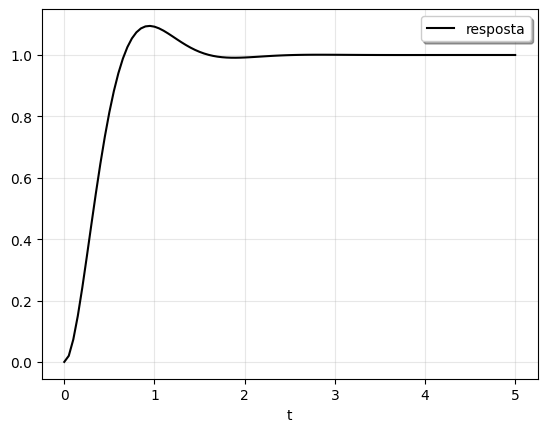

In [ ]:
!pip install control


import matplotlib.pyplot as plt
import numpy as np
import control as ctl
from control import TransferFunction

t = np.linspace(0,5, 101)

#FT da planta 1/(s+5)
planta = TransferFunction(1, [1, 5])
print(planta)

#FT do controle 17,36/s
controle = TransferFunction(17.36, [1,0])
print(controle)

#Malha aberta L=planta*controle
malha_aberta = ctl.series(planta, controle)
print(malha_aberta)

#Malha Fechada sys1 = linha de cima e sys2 = linha de baixo com realimentação
malha_fechada = ctl.feedback(malha_aberta, 1, sign=-1) #3a. default
print(malha_fechada)

#Dados dos polos
wn, damping, pole = ctl.damp(malha_fechada)#damp pega o fator de amortecimento


#Resposta ao degrau
tout, yout = ctl.step_response(malha_fechada, t, X0=0)

plt.plot(tout, yout, 'k', linewidth=1.5, label='resposta')
plt.legend(loc='best', shadow = True, framealpha=1)
plt.grid(alpha=0.3)
plt.xlabel('t')
plt.show()


